# Applied Statistical Analysis - Introduction

This notebook gives a high-level overview of what we will study in this course. Think of it as a map. We will not go deep into any one topic here; each topic gets its own dedicated notebook later. The aim today is to introduce the main ideas and explain why they are useful for students of BSIT and BSCS.

## Why statistics matters in computing

Most software today depends on data in some way. A few examples close to home:

- An app collects user clicks. We want to know which feature is actually being used.
- A new release ships. We want to check whether the bug rate has really gone down.
- A spam filter is trained on emails. We want to measure how well it works.
- A game tweaks a setting. We want to see whether players stay longer because of it.

Statistics is the set of tools that lets us answer these questions carefully, instead of relying on hunches.


## What this notebook covers

We will look briefly at four big ideas:

1. Descriptive statistics - summarising data we already have.
2. Inferential statistics - making careful guesses about a larger group from a small sample.
3. Hypothesis testing - deciding whether a change is real or just noise.
4. Modelling and machine learning - using data to make predictions.

At the end there is a short roadmap of the other notebooks in this course.


## 0. Setup

We will use a few standard Python libraries. If any are missing, install them with:

```
pip install numpy pandas matplotlib seaborn scipy scikit-learn
```


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4)

# A reproducible random number generator so everyone sees the same numbers.
rng = np.random.default_rng(42)

print("Libraries loaded.")


Libraries loaded.


## 1. Descriptive statistics

Suppose 30 students have just taken a quiz. Before doing anything fancy, we usually want a quick summary of how the class did.

There are three natural questions to ask of any dataset:

| Question | Common tools |
|----------|--------------|
| What is a typical value? | Mean, median, mode |
| How spread out are the values? | Standard deviation, range |
| Are there any unusual values? | Box plot, minimum, maximum |

Most descriptive statistics is just careful book-keeping with names attached.


In [2]:
# Imaginary quiz scores out of 100.
scores = rng.normal(loc=72, scale=10, size=30).round().clip(0, 100).astype(int)
print("Scores:", scores)

print(f"\nMean   : {np.mean(scores):.1f}")
print(f"Median : {np.median(scores):.1f}")
print(f"Std dev: {np.std(scores, ddof=1):.1f}")
print(f"Min/Max: {scores.min()} / {scores.max()}")


Scores: [75 62 80 81 52 59 73 69 72 63 81 80 73 83 77 63 76 62 81 72 70 65 84 70
 68 68 77 76 76 76]

Mean   : 72.1
Median : 73.0
Std dev: 7.9
Min/Max: 52 / 84


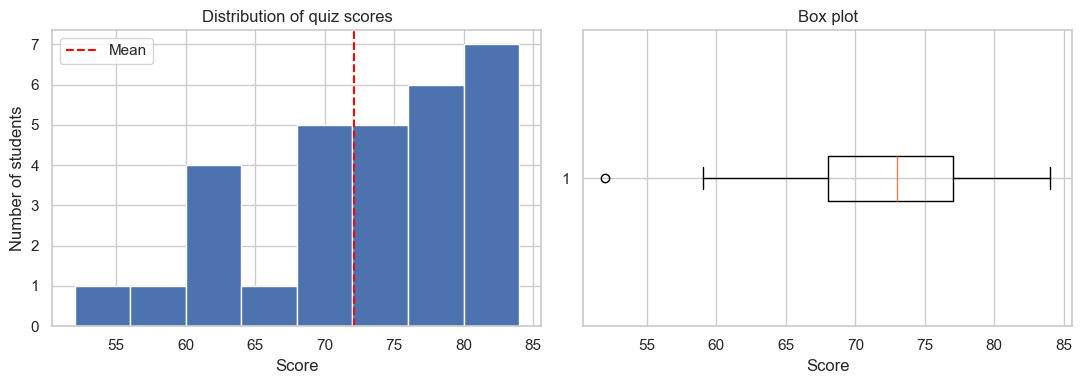

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(scores, bins=8, color="#4C72B0", edgecolor="white")
axes[0].axvline(np.mean(scores), color="red", linestyle="--", label="Mean")
axes[0].set_title("Distribution of quiz scores")
axes[0].set_xlabel("Score")
axes[0].set_ylabel("Number of students")
axes[0].legend()

axes[1].boxplot(scores, vert=False)
axes[1].set_title("Box plot")
axes[1].set_xlabel("Score")

plt.tight_layout()
plt.show()


Descriptive statistics only describes the data we have in front of us. It does not, by itself, make any claim about students who were not in the room.

For a fuller treatment - distributions, the Central Limit Theorem, and so on - see `StatisticsFoundations.ipynb`.


## 2. Inferential statistics

In practice we almost never measure the entire group we care about. We measure a small sample and try to draw conclusions about the larger population.

| Term | Meaning | Example |
|------|---------|---------|
| Population | The entire group of interest | All BSIT students in Nepal |
| Sample | A subset that we actually measure | 50 BSIT students from one college |
| Parameter (μ, σ) | A true value of the population, usually unknown | Average screen time of all students |
| Statistic (x̄, s) | A value computed from the sample | Average screen time in our 50-student survey |

The central insight is that a reasonably sized random sample can tell us a lot about the whole population, even though we never measure most of it.


In [4]:
# Pretend the true average daily screen time across all students is 5.0 hours.
# In a real study we would not know this; we have to estimate it.
TRUE_MEAN = 5.0
TRUE_STD  = 1.5

# Suppose we can survey only 40 students.
sample = rng.normal(TRUE_MEAN, TRUE_STD, size=40)

print(f"Sample of {len(sample)} students:")
print(f"  Sample mean         = {sample.mean():.2f} hours")
print(f"  Sample std deviation = {sample.std(ddof=1):.2f} hours")
print(f"\nTrue population mean (usually unknown): {TRUE_MEAN} hours")
print(f"Difference from the truth: {abs(sample.mean() - TRUE_MEAN):.2f} hours")


Sample of 40 students:
  Sample mean         = 5.13 hours
  Sample std deviation = 1.19 hours

True population mean (usually unknown): 5.0 hours
Difference from the truth: 0.13 hours


With this kind of reasoning we can report something like *students spend roughly 5 hours per day on their phones, give or take 0.2 hours.* The "give or take" part is what inferential statistics is all about.


## 3. Hypothesis testing

Imagine we change the colour of the sign-up button on a website from blue to green. Sign-ups go from about 100 per day to about 112 per day.

That looks promising. But sign-ups normally fluctuate from one day to the next anyway. Is the increase a real effect of the new colour, or just ordinary day-to-day noise? Hypothesis testing is the standard way to answer this.

### A four-step recipe

1. State two competing claims:
   - **H₀ (null hypothesis)**: nothing has actually changed.
   - **H₁ (alternative hypothesis)**: something has changed.
2. Choose a significance level α (commonly 0.05).
3. Compute a **p-value**: assuming H₀ is true, how likely is data at least as extreme as what we saw?
4. Decide:
   - If p < α, reject H₀. The change is statistically significant.
   - If p ≥ α, do not reject H₀. The data could plausibly have arisen by chance.


In [5]:
# A small example. We want to know whether students at our college sleep less than the
# national average of 7 hours per night.
national_avg = 7.0  # the no-effect baseline (H0: mu = 7)

# A survey of 30 students gives us their hours of sleep.
our_sample = rng.normal(loc=6.4, scale=1.1, size=30)

# scipy does the arithmetic for us.
t_stat, p_value = stats.ttest_1samp(our_sample, popmean=national_avg)

print(f"Sample mean : {our_sample.mean():.2f} hours")
print(f"t-statistic : {t_stat:.2f}")
print(f"p-value     : {p_value:.4f}")

if p_value < 0.05:
    print("\np < 0.05, so we reject H0. The average for our students differs from 7 hours.")
else:
    print("\np >= 0.05, so we do not reject H0. The data is consistent with the national average.")


Sample mean : 6.07 hours
t-statistic : -6.44
p-value     : 0.0000

p < 0.05, so we reject H0. The average for our students differs from 7 hours.


This same idea sits underneath every A/B test you have ever heard of, from website redesigns to clinical trials. We will return to it in detail in `StatisticsFoundations.ipynb`.


## 4. Modelling and machine learning

Once we trust our data, we often want to use it to make predictions. That is the job of a model.

There are two broad families:

**Supervised learning** uses data with known answers to learn a rule.

| Sub-type | What it predicts | Example |
|----------|------------------|---------|
| Regression | A number | House price from house size |
| Classification | A category | Whether an email is spam |

**Unsupervised learning** has no known answers. It looks for structure on its own.

- *Clustering*: grouping similar items together.
- *Dimensionality reduction*: compressing data while keeping what matters.

Below is a small taste of regression: predicting marks from study hours.


Best-fit line: marks = 7.81 * hours + 20.12
R-squared (a measure of fit, 0 to 1): 0.926


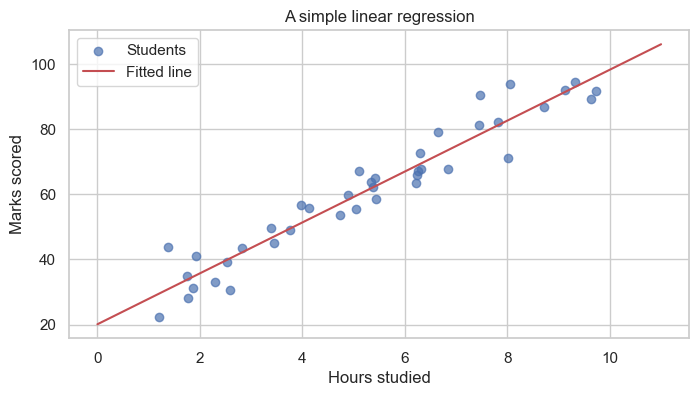

In [6]:
# Hours studied versus marks scored, for 40 imaginary students.
hours = rng.uniform(1, 10, size=40)
marks = 8 * hours + 20 + rng.normal(0, 6, size=40)  # roughly 8 marks per hour, plus noise

# Fit a straight line to the data.
slope, intercept, r, _, _ = stats.linregress(hours, marks)

print(f"Best-fit line: marks = {slope:.2f} * hours + {intercept:.2f}")
print(f"R-squared (a measure of fit, 0 to 1): {r**2:.3f}")

plt.scatter(hours, marks, alpha=0.7, label="Students")
xs = np.linspace(0, 11, 50)
plt.plot(xs, slope * xs + intercept, "r-", label="Fitted line")
plt.xlabel("Hours studied")
plt.ylabel("Marks scored")
plt.title("A simple linear regression")
plt.legend()
plt.show()


A model is just a rule learned from data, and the simplest useful rule is a straight line. We will spend a fair amount of time on this idea in later notebooks.

- For a careful look at linear regression, see `LinearRegression.ipynb`.
- For how the slope and intercept above are chosen, see `ParameterEstimation.ipynb`.
- For overfitting and how we judge a model's quality, see `Regularization&Metrics.ipynb`.


## 5. Course roadmap

Here is the order in which the notebooks are meant to be read. Each one builds on the previous.

| # | Notebook | Topic |
|---|----------|-------|
| 1 | `InstallationGuide.ipynb` | Setting up Python, Jupyter, and the libraries we use |
| 2 | `Introduction.ipynb` (this one) | Big-picture overview of the course |
| 3 | `StatisticsFoundations.ipynb` | Descriptive and inferential statistics, probability, distributions, CLT, hypothesis testing |
| 4 | `MLConcepts.ipynb` | Vocabulary and ideas behind AI, data science, and the three families of machine learning |
| 5 | `ParameterEstimation.ipynb` | How models learn their parameters from data |
| 6 | `LinearRegression.ipynb` | Predicting numbers with linear models |
| 7 | `Regularization&Metrics.ipynb` | Avoiding overfitting and measuring model quality |
| 8 | `TimeSeries.ipynb` | Working with data that has a time order: trend, seasonality, autocorrelation, forecasting |
| 9 | `TimeSeriesModels.ipynb` | Statistical models (AR, MA, ARMA, ARIMA, SARIMA, SARIMAX) and modern approaches (N-BEATS, TFT, hierarchical reconciliation) on a stock-style dataset |

### A few suggestions for studying

- Run every cell yourself instead of just reading. Statistics becomes much clearer once you can change numbers and see what happens.
- When something does not feel right, change a parameter on purpose to break it, and then put it back. Small experiments build intuition.
- Most ideas in this course can be drawn. If you can sketch the picture, you usually understand the maths.

### A small closing demonstration

To finish, let us check that the inference idea actually works. We will pretend we know the true average of a population, then take many random samples and look at the distribution of their means.

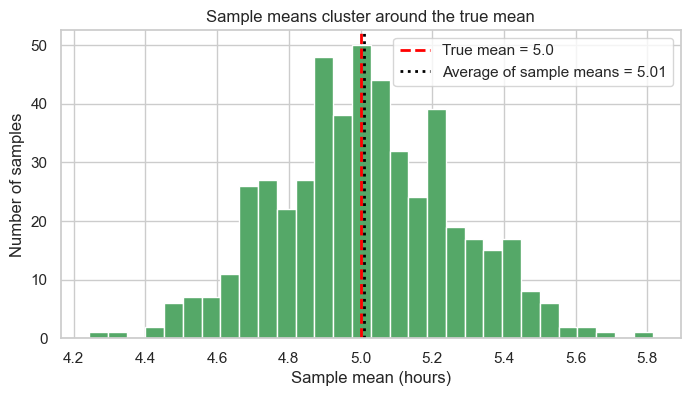

In [7]:
# Pretend the true average screen time across all students is 5.0 hours.
true_mean = 5.0

# Take 500 different random samples of 40 students each.
sample_means = [rng.normal(true_mean, 1.5, size=40).mean() for _ in range(500)]

plt.hist(sample_means, bins=30, color="#55A868", edgecolor="white")
plt.axvline(true_mean, color="red", linestyle="--", lw=2,
            label=f"True mean = {true_mean}")
plt.axvline(np.mean(sample_means), color="black", linestyle=":", lw=2,
            label=f"Average of sample means = {np.mean(sample_means):.2f}")
plt.title("Sample means cluster around the true mean")
plt.xlabel("Sample mean (hours)")
plt.ylabel("Number of samples")
plt.legend()
plt.show()


The sample means are not all equal to the true mean, but they are scattered tightly around it. This is the basic reason inferential statistics is reliable.

When you are ready, move on to `StatisticsFoundations.ipynb`.
